# ✈️ Flight Price Prediction
## Notebook 2: Preprocessing & Feature Engineering

**Цель:** Очистить данные, создать новые признаки, закодировать категориальные переменные, сделать корректный train/val/test сплит.

## 0. Импорты

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import warnings
import os

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../data/plots', exist_ok=True)

print('Импорты выполнены ✅')

Импорты выполнены ✅


## 1. Загрузка данных

In [2]:
df = pd.read_csv('../data/raw/Clean_Dataset.csv')

# Удаляем ненужные колонки
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f'Загружено: {df.shape[0]:,} строк, {df.shape[1]} колонок')
df.head(3)

Загружено: 300,153 строк, 11 колонок


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


## 2. Базовая очистка

In [3]:
# Пропуски
print('Пропущенные значения:', df.isnull().sum().sum())

# Дубли
dupes = df.duplicated().sum()
if dupes > 0:
    df = df.drop_duplicates()
    print(f'Удалено {dupes} дублей')
else:
    print('Дубликатов нет ✅')

# Выбросы в цене (IQR метод)
Q1 = df['price'].quantile(0.01)
Q3 = df['price'].quantile(0.99)
before = len(df)
df = df[(df['price'] >= Q1) & (df['price'] <= Q3)]
print(f'Удалено выбросов по цене (1-99 перцентиль): {before - len(df)} строк')
print(f'Итого строк: {len(df):,}')

Пропущенные значения: 0
Дубликатов нет ✅
Удалено выбросов по цене (1-99 перцентиль): 5452 строк
Итого строк: 294,701


## 3. Feature Engineering — создаём новые признаки

In [4]:
print('Признаков до FE:', df.shape[1])

# 1. Маршрут (source + destination)
df['route'] = df['source_city'] + '_' + df['destination_city']

# 2. Является ли рейс прямым
df['is_direct'] = (df['stops'] == 'zero').astype(int)

# 3. Бизнес-класс (бинарный)
df['is_business'] = (df['class'] == 'Business').astype(int)

# 4. Срочность покупки (бинарный: меньше 7 дней до вылета)
df['is_last_minute'] = (df['days_left'] <= 7).astype(int)

# 5. Категория заблаговременности
def booking_category(days):
    if days <= 7:
        return 'last_minute'
    elif days <= 30:
        return 'short_advance'
    elif days <= 60:
        return 'medium_advance'
    else:
        return 'long_advance'

df['booking_category'] = df['days_left'].apply(booking_category)

# 6. Длительность в минутах (если нужна другая шкала)
df['duration_minutes'] = df['duration'] * 60

# 7. Нормированная длительность (длинный/короткий рейс)
median_duration = df['duration'].median()
df['is_long_flight'] = (df['duration'] > median_duration).astype(int)

print('Признаков после FE:', df.shape[1])
print('\nНовые признаки:')
new_features = ['route', 'is_direct', 'is_business', 'is_last_minute',
                'booking_category', 'duration_minutes', 'is_long_flight']
print(df[new_features].head())

Признаков до FE: 11
Признаков после FE: 18

Новые признаки:
          route  is_direct  is_business  is_last_minute booking_category  \
0  Delhi_Mumbai          1            0               1      last_minute   
1  Delhi_Mumbai          1            0               1      last_minute   
2  Delhi_Mumbai          1            0               1      last_minute   
3  Delhi_Mumbai          1            0               1      last_minute   
4  Delhi_Mumbai          1            0               1      last_minute   

   duration_minutes  is_long_flight  
0             130.2               0  
1             139.8               0  
2             130.2               0  
3             135.0               0  
4             139.8               0  


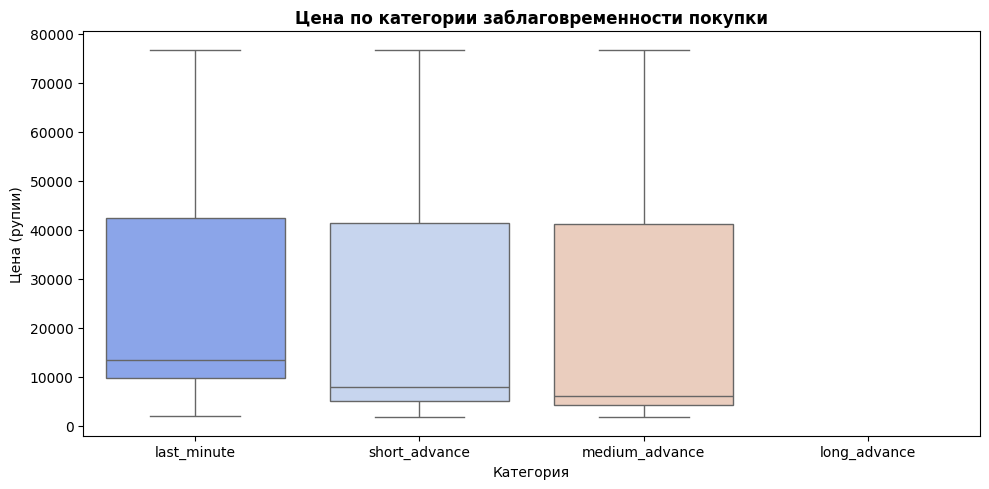

In [5]:
# Визуализация: цена по категории заблаговременности
order = ['last_minute', 'short_advance', 'medium_advance', 'long_advance']
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='booking_category', y='price', order=order, palette='coolwarm')
plt.title('Цена по категории заблаговременности покупки', fontweight='bold')
plt.xlabel('Категория')
plt.ylabel('Цена (рупии)')
plt.tight_layout()
plt.savefig('../data/plots/booking_category_price.png', bbox_inches='tight')
plt.show()

## 4. Кодирование категориальных признаков

In [6]:
df_encoded = df.copy()

# Порядковые признаки (со смыслом)
# stops: zero < one < two_or_more
stops_order = [['zero', 'one', 'two_or_more']]
oe_stops = OrdinalEncoder(categories=stops_order)
df_encoded['stops_encoded'] = oe_stops.fit_transform(df_encoded[['stops']])

# departure_time и arrival_time: порядок суток
time_order = [['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night']]
oe_time = OrdinalEncoder(categories=time_order, handle_unknown='use_encoded_value', unknown_value=-1)
df_encoded['departure_time_encoded'] = oe_time.fit_transform(df_encoded[['departure_time']])
df_encoded['arrival_time_encoded'] = oe_time.fit_transform(df_encoded[['arrival_time']])

# booking_category
booking_order = [['long_advance', 'medium_advance', 'short_advance', 'last_minute']]
oe_booking = OrdinalEncoder(categories=booking_order)
df_encoded['booking_category_encoded'] = oe_booking.fit_transform(df_encoded[['booking_category']])

# Номинальные категориальные — Label Encoding
le = LabelEncoder()
for col in ['airline', 'source_city', 'destination_city', 'route', 'class', 'flight']:
    df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col])

print('Кодирование выполнено ✅')
print('Итого колонок:', df_encoded.shape[1])

Кодирование выполнено ✅
Итого колонок: 28


## 5. Финальный набор признаков

In [7]:
# Признаки для моделей
FEATURES = [
    # Числовые
    'duration',
    'days_left',
    'duration_minutes',
    # Бинарные
    'is_direct',
    'is_business',
    'is_last_minute',
    'is_long_flight',
    # Закодированные порядковые
    'stops_encoded',
    'departure_time_encoded',
    'arrival_time_encoded',
    'booking_category_encoded',
    # Закодированные номинальные
    'airline_encoded',
    'source_city_encoded',
    'destination_city_encoded',
    'route_encoded',
    'class_encoded',
]

TARGET = 'price'

print(f'Количество признаков: {len(FEATURES)}')
print('Список признаков:', FEATURES)

Количество признаков: 16
Список признаков: ['duration', 'days_left', 'duration_minutes', 'is_direct', 'is_business', 'is_last_minute', 'is_long_flight', 'stops_encoded', 'departure_time_encoded', 'arrival_time_encoded', 'booking_category_encoded', 'airline_encoded', 'source_city_encoded', 'destination_city_encoded', 'route_encoded', 'class_encoded']


## 6. Train / Val / Test сплит

**Стратегия:** 70% train / 15% val / 15% test — стандартный сплит для регрессии.

**Защита от data leak:** датасет не содержит временных рядов (данные собраны в один момент), поэтому случайный сплит корректен. Если бы данные были последовательными во времени, использовали бы временной сплит.

In [8]:
X = df_encoded[FEATURES]
y = df_encoded[TARGET]

# Сначала отделяем тест
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED
)

# Затем разделяем оставшееся на train и val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=SEED
)

print(f'Train: {len(X_train):,} строк ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val:   {len(X_val):,} строк ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test:  {len(X_test):,} строк ({len(X_test)/len(X)*100:.1f}%)')

# Проверяем отсутствие пересечений
assert len(set(X_train.index) & set(X_val.index)) == 0
assert len(set(X_train.index) & set(X_test.index)) == 0
assert len(set(X_val.index) & set(X_test.index)) == 0
print('\nПересечений между выборками нет ✅')

Train: 206,290 строк (70.0%)
Val:   44,205 строк (15.0%)
Test:  44,206 строк (15.0%)

Пересечений между выборками нет ✅


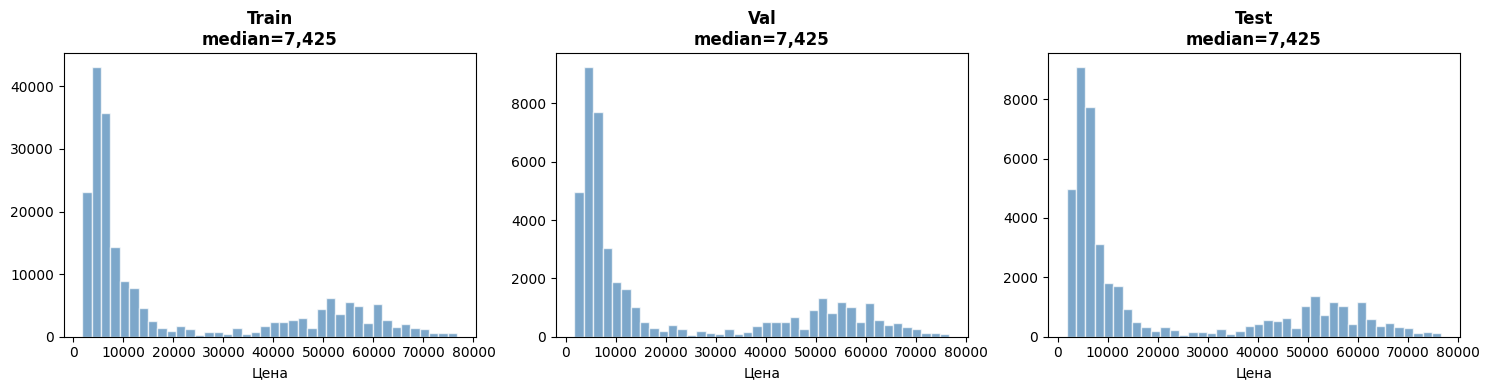

In [9]:
# Проверяем, что распределение цены похоже во всех выборках
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_split) in zip(axes, [('Train', y_train), ('Val', y_val), ('Test', y_test)]):
    ax.hist(y_split, bins=40, alpha=0.7, color='steelblue', edgecolor='white')
    ax.set_title(f'{name}\nmedian={y_split.median():,.0f}', fontweight='bold')
    ax.set_xlabel('Цена')
plt.tight_layout()
plt.savefig('../data/plots/split_distribution.png', bbox_inches='tight')
plt.show()

## 7. Сохранение обработанных данных

In [10]:
# Сохраняем все части датасета
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_val.to_csv('../data/processed/X_val.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_val.to_csv('../data/processed/y_val.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

# Сохраняем полный обработанный датасет
df_encoded.to_csv('../data/processed/df_processed.csv', index=False)

# Сохраняем список признаков
import json
with open('../data/processed/features.json', 'w') as f:
    json.dump({'features': FEATURES, 'target': TARGET}, f)

print('Данные сохранены в data/processed/ ✅')
print(f'X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}')

Данные сохранены в data/processed/ ✅
X_train: (206290, 16), X_val: (44205, 16), X_test: (44206, 16)
